In [3]:
# ─── 1. IMPORT LIBRARIES & SETUP ───────────────────────────────────────────
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

DATA_DIR = r"C:\Users\Admin\Downloads\Compressed\FaceForensics++\data_flat"  # adjust as needed
SEED = 42

# ─── 2. LOAD PRETRAINED BASE MODELS ────────────────────────────────────────
model_x = load_model("xception_deepfake.h5")
model_v = load_model("vgg19.h5")
model_e = load_model("efficientnetb0.h5")
model_r = load_model("resnet50.h5")
model_m = load_model("mobilenetv2.h5")

# ─── 3. PREPARE VALIDATION DATA GENERATORS ────────────────────────────────
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
gen_224 = datagen.flow_from_directory(
    DATA_DIR, target_size=(224,224),
    batch_size=32, class_mode="binary",
    subset="validation", shuffle=False
)
gen_299 = datagen.flow_from_directory(
    DATA_DIR, target_size=(299,299),
    batch_size=32, class_mode="binary",
    subset="validation", shuffle=False
)
y_true = gen_224.classes  # same order for both gens

# ─── 4. GENERATE BASE‑MODEL PREDICTIONS ────────────────────────────────────
pred_x = model_x.predict(gen_299, verbose=1)
pred_v = model_v.predict(gen_224, verbose=1)
pred_e = model_e.predict(gen_224, verbose=1)
pred_r = model_r.predict(gen_224, verbose=1)
pred_m = model_m.predict(gen_224, verbose=1)

# Stack into (n_samples × 5) meta‑feature matrix
X_meta = np.hstack([pred_x, pred_v, pred_e, pred_r, pred_m])

# ─── 5. HOLD‑OUT SPLIT FOR GENERALIZATION TEST ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_meta, y_true, test_size=0.3,
    stratify=y_true, random_state=SEED
)

# ─── 6. SCALE META‑FEATURES ────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ─── 7. RANDOM FOREST META‑MODEL ──────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=SEED
)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
print("🔹 RF Accuracy:", accuracy_score(y_test, y_pred_rf))

# ─── 8. LOGISTIC REGRESSION META‑MODEL ────────────────────────────────────
lr = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=SEED
)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
print("🔹 LR Accuracy:", accuracy_score(y_test, y_pred_lr))

# ─── 9. XGBOOST META‑MODEL ────────────────────────────────────────────────
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=SEED
)
xgb.fit(X_train_scaled, y_train)
y_pred_xgb  = xgb.predict(X_test_scaled)
y_prob_xgb  = xgb.predict_proba(X_test_scaled)[:,1]
print("🔹 XGB Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("🔹 XGB ROC AUC:", roc_auc_score(y_test, y_prob_xgb))

# ─── 10. STRATIFIED K‑FOLD CV WITH RANDOM FOREST ──────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_accuracies = []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_meta, y_true), 1):
    X_tr, X_va = X_meta[tr_idx], X_meta[va_idx]
    y_tr, y_va = y_true[tr_idx], y_true[va_idx]
    sc = StandardScaler().fit(X_tr)
    X_tr_s, X_va_s = sc.transform(X_tr), sc.transform(X_va)
    rf_cv = RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        class_weight="balanced",
        random_state=SEED
    ).fit(X_tr_s, y_tr)
    acc = accuracy_score(y_va, rf_cv.predict(X_va_s))
    cv_accuracies.append(acc)
print("🔹 5‑Fold RF CV Accuracies:", cv_accuracies)
print("🔹 Mean CV Accuracy:", np.mean(cv_accuracies))

# ─── 11. NEURAL‑NET META‑MODEL (ADAM OPTIMIZER) ────────────────────────────
model_meta = Sequential([
    Dense(64, activation="relu", input_shape=(5,)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])
model_meta.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)
history = model_meta.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=25, batch_size=32, verbose=2
)
y_pred_nn = (model_meta.predict(X_test_scaled) > 0.5).astype(int).ravel()
print("🔹 NN Meta Accuracy:", accuracy_score(y_test, y_pred_nn))

# ─── 12. FINAL EVALUATION REPORT ──────────────────────────────────────────
for name, preds in [
    ("RF",   y_pred_rf),
    ("LR",   y_pred_lr),
    ("XGB",  y_pred_xgb),
    ("NN",   y_pred_nn)
]:
    print(f"\n=== {name} Classification Report ===")
    print(classification_report(y_test, preds, target_names=["Fake","Real"]))
    print("Confusion Matrix:\n", confusion_matrix(y_test, preds))


Found 2112 images belonging to 2 classes.
Found 2112 images belonging to 2 classes.
66/66 [==============================] - 31s 462ms/step
🔹 RF Accuracy: 0.6545741324921136
🔹 LR Accuracy: 0.5757097791798107


C:\Users\Admin\anaconda3\envs\deepfake_detection\lib\site-packages\xgboost\core.py:158: UserWarning: [16:09:09] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


🔹 XGB Accuracy: 0.6498422712933754
🔹 XGB ROC AUC: 0.718223736968725
🔹 5‑Fold RF CV Accuracies: [0.6950354609929078, 0.6359338061465721, 0.6966824644549763, 0.6469194312796208, 0.6800947867298578]
🔹 Mean CV Accuracy: 0.670933189920787
Epoch 1/25
47/47 - 1s - loss: 0.6763 - accuracy: 0.5812 - val_loss: 0.6577 - val_accuracy: 0.6167 - 738ms/epoch - 16ms/step
Epoch 2/25
47/47 - 0s - loss: 0.6551 - accuracy: 0.6231 - val_loss: 0.6484 - val_accuracy: 0.6309 - 47ms/epoch - 1ms/step
Epoch 3/25
47/47 - 0s - loss: 0.6472 - accuracy: 0.6319 - val_loss: 0.6485 - val_accuracy: 0.6325 - 79ms/epoch - 2ms/step
Epoch 4/25
47/47 - 0s - loss: 0.6423 - accuracy: 0.6340 - val_loss: 0.6405 - val_accuracy: 0.6656 - 79ms/epoch - 2ms/step
Epoch 5/25
47/47 - 0s - loss: 0.6378 - accuracy: 0.6407 - val_loss: 0.6410 - val_accuracy: 0.6483 - 80ms/epoch - 2ms/step
Epoch 6/25
47/47 - 0s - loss: 0.6339 - accuracy: 0.6461 - val_loss: 0.6354 - val_accuracy: 0.6577 - 79ms/epoch - 2ms/step
Epoch 7/25
47/47 - 0s - loss: 0.

In [18]:
# ─── 1. IMPORT LIBRARIES & SETUP ───────────────────────────────────────────
import numpy as np
import cv2
import joblib
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import img_to_array
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier


# Paths to your saved models
BASE_MODELS = {
    "x": ("xception_deepfake.h5", (299,299)),
    "v": ("vgg19.h5",          (224,224)),
    "e": ("efficientnetb0.h5", (224,224)),
    "r": ("resnet50.h5",       (224,224)),
    "m": ("mobilenetv2.h5",    (224,224)),
}
META_MODEL_PATHS = {
    "rf":  "rf_meta.pkl",
    "lr":  "lr_meta.pkl",
    "xgb": "xgb_meta.json",
    "nn":  "nn_meta.h5"
}

# ─── 2. SAVE YOUR TRAINED META-MODELS ──────────────────────────────────────
# (Run once, after training)
joblib.dump(rf,  META_MODEL_PATHS["rf"])
joblib.dump(lr,  META_MODEL_PATHS["lr"])
xgb.save_model(META_MODEL_PATHS["xgb"])
model_meta.save(META_MODEL_PATHS["nn"])

C:\Users\Admin\anaconda3\envs\deepfake_detection\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [40]:
# ─── 3. LOAD SAVED BASE & META-MODELS ──────────────────────────────────────
# Base CNNs:
base_models = {
    k: load_model(path) for k,(path,_) in BASE_MODELS.items()
}
# Meta-learners:
rf_meta  = joblib.load(META_MODEL_PATHS["rf"])
lr_meta  = joblib.load(META_MODEL_PATHS["lr"])
xgb_meta = XGBClassifier()
xgb_meta.load_model(META_MODEL_PATHS["xgb"])
nn_meta  = load_model(META_MODEL_PATHS["nn"])




In [58]:

# ─── 4. SINGLE IMAGE PREPROCESSING ────────────────────────────────────────
def preprocess_image(img_path, target_size):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, target_size)
    arr = img_to_array(img) / 255.0
    return np.expand_dims(arr, axis=0)

 #Example usage:
img_path = "C:/Users/Admin/Downloads/Doni_Base_Real.jpg"
img_path1 = "C:/Users/Admin/Downloads/doni_base_fake.png"
X_base = []
for key, (model, (_, size)) in zip(base_models, BASE_MODELS.items()):
    # actually iterate properly:
    pass


In [54]:
# ─── 5. BUILD META-FEATURE VECTOR ─────────────────────────────────────────
def make_meta_vector(img_path):
    feats = []
    for k,(model,( _, size)) in zip(base_models.keys(), BASE_MODELS.items()):
        target_size = BASE_MODELS[k][1]
        inp = preprocess_image(img_path, target_size)
        pred = base_models[k].predict(inp)
        feats.append(pred.ravel())
    meta_vec = np.hstack(feats).reshape(1,-1)
    return scaler.transform(meta_vec)


In [56]:
# ─── 6. PREDICT WITH YOUR META-MODELS ────────────────────────────────────
meta_X = make_meta_vector(img_path)

# 2. RANDOM FOREST (hold-out split RF)
proba_rf = rf_meta.predict_proba(meta_X)[0]        # [P(Fake), P(Real)]
label_rf = "Real" if proba_rf[1] > proba_rf[0] else "Fake"
print(f"🔹 RF Prediction: {label_rf} ({max(proba_rf)*100:.2f}% confidence)")
print(f"    • P(Fake)={proba_rf[0]*100:.2f}%, P(Real)={proba_rf[1]*100:.2f}%\n")

# 3. LOGISTIC REGRESSION
proba_lr = lr_meta.predict_proba(meta_X)[0]
label_lr = "Real" if proba_lr[1] > proba_lr[0] else "Fake"
print(f"🔹 LR Prediction: {label_lr} ({max(proba_lr)*100:.2f}% confidence)")
print(f"    • P(Fake)={proba_lr[0]*100:.2f}%, P(Real)={proba_lr[1]*100:.2f}%\n")

# 4. XGBOOST
proba_xgb = xgb_meta.predict_proba(meta_X)[0]
label_xgb = "Real" if proba_xgb[1] > proba_xgb[0] else "Fake"
print(f"🔹 XGB Prediction: {label_xgb} ({max(proba_xgb)*100:.2f}% confidence)")
print(f"    • P(Fake)={proba_xgb[0]*100:.2f}%, P(Real)={proba_xgb[1]*100:.2f}%\n")

# 5. NEURAL-NET META-MODEL
prob_nn = nn_meta.predict(meta_X)[0][0]   # probability of the positive class (“Real”)
label_nn = "Real" if prob_nn > 0.5 else "Fake"
conf_nn  = prob_nn if prob_nn > 0.5 else (1 - prob_nn)
print(f"🔹 NN Prediction: {label_nn} ({conf_nn*100:.2f}% confidence)")
print(f"    • P(Real)={prob_nn*100:.2f}%, P(Fake)={(1-prob_nn)*100:.2f}%\n")

# 6. K-FOLD RF (retrained on full meta-dataset)
proba_kf = rf_kfold.predict_proba(meta_X)[0]
label_kf = "Real" if proba_kf[1] > proba_kf[0] else "Fake"
print(f"🔹 K-Fold RF Prediction: {label_kf} ({max(proba_kf)*100:.2f}% confidence)")
print(f"    • P(Fake)={proba_kf[0]*100:.2f}%, P(Real)={proba_kf[1]*100:.2f}%")

1/1 [==============================] - 0s 41ms/step
🔹 RF Prediction: Real (54.00% confidence)
    • P(Fake)=46.00%, P(Real)=54.00%

🔹 LR Prediction: Fake (52.78% confidence)
    • P(Fake)=52.78%, P(Real)=47.22%

🔹 XGB Prediction: Real (80.06% confidence)
    • P(Fake)=19.94%, P(Real)=80.06%

1/1 [==============================] - 0s 20ms/step
🔹 NN Prediction: Fake (52.80% confidence)
    • P(Real)=47.20%, P(Fake)=52.80%

🔹 K-Fold RF Prediction: Real (56.56% confidence)
    • P(Fake)=43.44%, P(Real)=56.56%


In [62]:
meta_X_1 = make_meta_vector(img_path1)
# 2. RANDOM FOREST (hold-out split RF)
proba_rf = rf_meta.predict_proba(meta_X_1)[0]        # [P(Fake), P(Real)]
label_rf = "Real" if proba_rf[1] > proba_rf[0] else "Fake"
print(f"🔹 RF Prediction: {label_rf} ({max(proba_rf)*100:.2f}% confidence)")
print(f"    • P(Fake)={proba_rf[0]*100:.2f}%, P(Real)={proba_rf[1]*100:.2f}%\n")

# 3. LOGISTIC REGRESSION
proba_lr = lr_meta.predict_proba(meta_X_1)[0]
label_lr = "Real" if proba_lr[1] > proba_lr[0] else "Fake"
print(f"🔹 LR Prediction: {label_lr} ({max(proba_lr)*100:.2f}% confidence)")
print(f"    • P(Fake)={proba_lr[0]*100:.2f}%, P(Real)={proba_lr[1]*100:.2f}%\n")

# 4. XGBOOST
proba_xgb = xgb_meta.predict_proba(meta_X_1)[0]
label_xgb = "Real" if proba_xgb[1] > proba_xgb[0] else "Fake"
print(f"🔹 XGB Prediction: {label_xgb} ({max(proba_xgb)*100:.2f}% confidence)")
print(f"    • P(Fake)={proba_xgb[0]*100:.2f}%, P(Real)={proba_xgb[1]*100:.2f}%\n")

# 5. NEURAL-NET META-MODEL
prob_nn = nn_meta.predict(meta_X_1)[0][0]   # probability of the positive class (“Real”)
label_nn = "Real" if prob_nn > 0.5 else "Fake"
conf_nn  = prob_nn if prob_nn > 0.5 else (1 - prob_nn)
print(f"🔹 NN Prediction: {label_nn} ({conf_nn*100:.2f}% confidence)")
print(f"    • P(Real)={prob_nn*100:.2f}%, P(Fake)={(1-prob_nn)*100:.2f}%\n")

# 6. K-FOLD RF (retrained on full meta-dataset)
proba_kf = rf_kfold.predict_proba(meta_X_1)[0]
label_kf = "Real" if proba_kf[1] > proba_kf[0] else "Fake"
print(f"🔹 K-Fold RF Prediction: {label_kf} ({max(proba_kf)*100:.2f}% confidence)")
print(f"    • P(Fake)={proba_kf[0]*100:.2f}%, P(Real)={proba_kf[1]*100:.2f}%")

1/1 [==============================] - 0s 47ms/step
🔹 RF Prediction: Real (84.50% confidence)
    • P(Fake)=15.50%, P(Real)=84.50%

🔹 LR Prediction: Fake (52.27% confidence)
    • P(Fake)=52.27%, P(Real)=47.73%

🔹 XGB Prediction: Real (96.28% confidence)
    • P(Fake)=3.72%, P(Real)=96.28%

1/1 [==============================] - 0s 21ms/step
🔹 NN Prediction: Real (81.19% confidence)
    • P(Real)=81.19%, P(Fake)=18.81%

🔹 K-Fold RF Prediction: Fake (57.54% confidence)
    • P(Fake)=57.54%, P(Real)=42.46%


In [102]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [120]:
pip install networkx matplotlib


   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 2.4 MB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.1 MB 3.4 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 3.5 MB/s eta 0:00:00


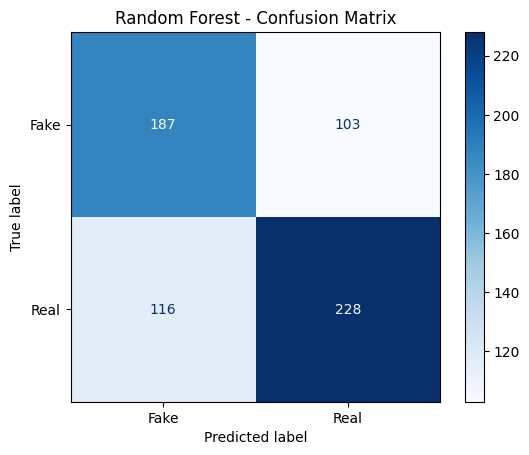

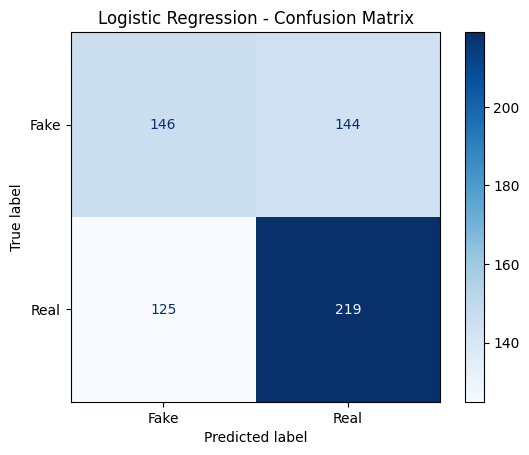

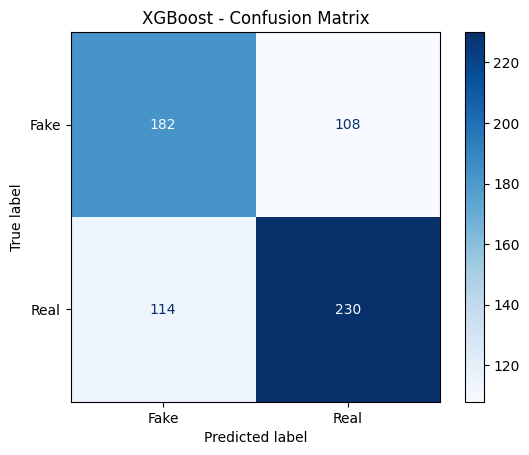

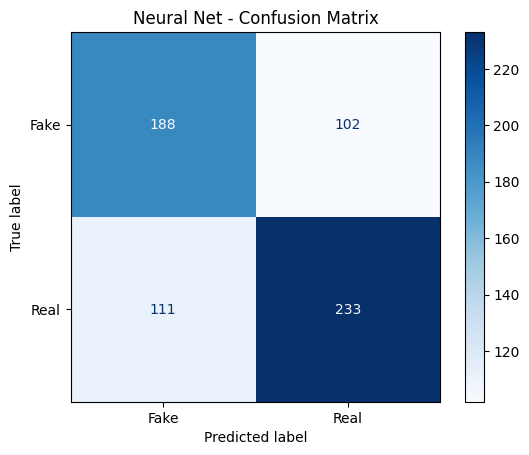

20/20 [==============================] - 0s 609us/step


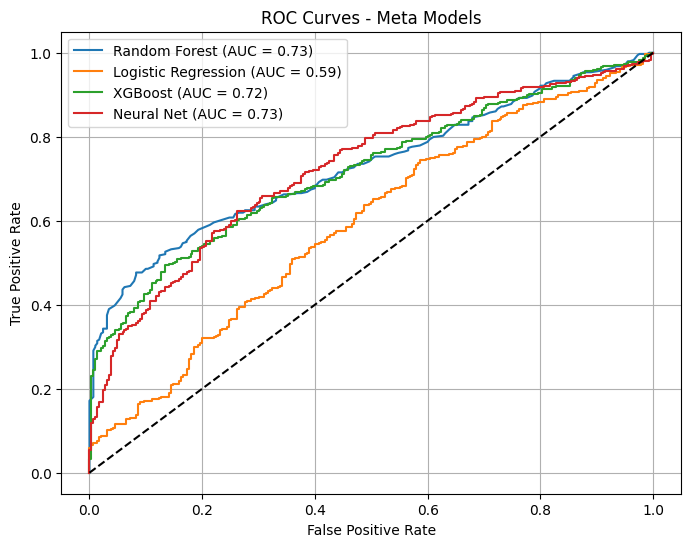

+---------------------+------------+
| Model               |   Accuracy |
+=====================+============+
| Random Forest       |   0.654574 |
+---------------------+------------+
| Logistic Regression |   0.57571  |
+---------------------+------------+
| XGBoost             |   0.649842 |
+---------------------+------------+
| Neural Net          |   0.664038 |
+---------------------+------------+


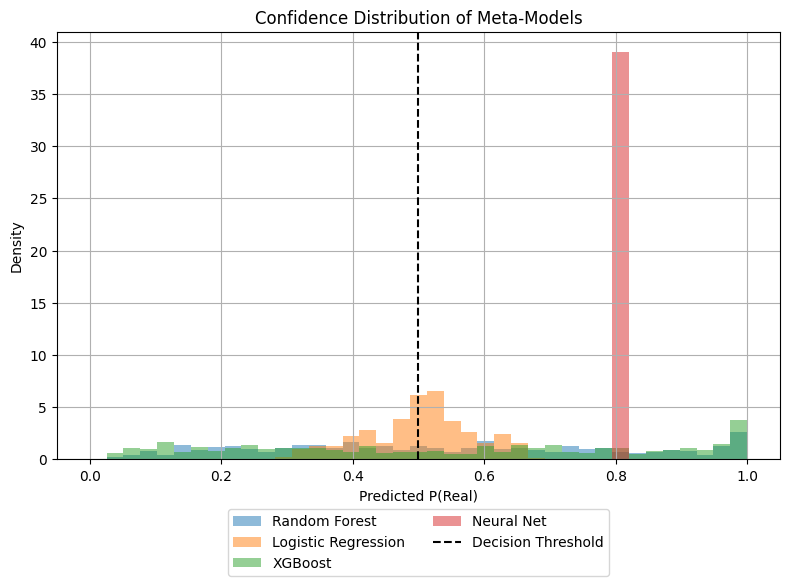

In [136]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay

save_path = r"C:\Users\Admin\Downloads\SVNIT\M.tech\2nd Sem\Minor project\Ensemble_Learning_Soft_Voting"

# --- 1. Plot Confusion Matrix ---
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{model_name} - Confusion Matrix")
    plt.show()

plot_conf_matrix(y_test, y_pred_rf, "Random Forest")
plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression")
plot_conf_matrix(y_test, y_pred_xgb, "XGBoost")
plot_conf_matrix(y_test, y_pred_nn, "Neural Net")

# --- 2. Plot ROC Curve ---
def plot_roc_curve(y_true, y_probs, model_name):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')
proba_rf = rf_meta.predict_proba(X_test_scaled)[:, 1]  # shape: (n_samples,) — OK!
proba_xgb = xgb_meta.predict_proba(X_test_scaled)[:, 1]
proba_lr = lr_meta.predict_proba(X_test_scaled)[:, 1]
#prob_nn = nn_meta.predict(meta_X_1)[0][0]

plt.figure(figsize=(8, 6))
plot_roc_curve(y_test, proba_rf, "Random Forest")
plot_roc_curve(y_test, proba_lr, "Logistic Regression")
plot_roc_curve(y_test, proba_xgb, "XGBoost")

plot_roc_curve(y_test, nn_meta.predict(X_test_scaled).ravel(), "Neural Net")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Meta Models")
plt.legend()
plt.grid(True)
plt.show()


# --- 3. Print Accuracy Table ---
from tabulate import tabulate

model_scores = [
    ["Random Forest", accuracy_score(y_test, y_pred_rf)],
    ["Logistic Regression", accuracy_score(y_test, y_pred_lr)],
    ["XGBoost", accuracy_score(y_test, y_pred_xgb)],
    ["Neural Net", accuracy_score(y_test, y_pred_nn)],
]

print(tabulate(model_scores, headers=["Model", "Accuracy"], tablefmt="grid"))


import matplotlib.pyplot as plt
bins = np.linspace(0, 1, 40)  # 40 equal-width bins in [0,1]
# Suppose proba_rf, proba_lr, proba_xgb, prob_nn all hold p(Real) values for y_test
plt.figure(figsize=(8,6))
plt.hist(proba_rf, bins=bins, density=True, alpha=0.5, label='Random Forest')
plt.hist(proba_lr, bins=bins, density=True, alpha=0.5, label='Logistic Regression')
plt.hist(proba_xgb, bins=bins, density=True, alpha=0.5, label='XGBoost')
plt.hist(prob_nn,     bins=bins, density=True, alpha=0.5, label='Neural Net')
plt.axvline(0.5, color='k',  linestyle='--', label='Decision Threshold')
plt.xlabel('Predicted P(Real)')
plt.ylabel('Density')
plt.title('Confidence Distribution of Meta-Models')
plt.grid(True)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()
plt.savefig('confidence_distribution.png')
plt.show()


In [130]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from tabulate import tabulate

# 1. where to save
BASE_DIR = r"C:\Users\Admin\Downloads\SVNIT\M.tech\2nd Sem\Minor project\Ensemble_Learning_Soft_Voting"
os.makedirs(BASE_DIR, exist_ok=True)

# 2. helper to map model names → short keys
KEY_MAP = {
    "Random Forest": "rf",
    "Logistic Regression": "lr",
    "XGBoost": "xgb",
    "Neural Net": "nn"
}

# --- 1. Plot & save Confusion Matrix ---
def plot_conf_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=["Fake", "Real"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"{model_name} – Confusion Matrix")

    # build filename
    key = KEY_MAP.get(model_name, model_name.lower().replace(" ", "_"))
    filename = os.path.join(BASE_DIR, f"cm_{key}.png")

    # save and close
    plt.savefig(filename, bbox_inches="tight")
    plt.close()
    print(f"Saved confusion matrix ⇒ {filename!r}")

# --- 2. Plot & save ROC Curve (all models on one plot) ---
def plot_and_save_roc(y_true, probas_dict):
    plt.figure(figsize=(8, 6))
    for model_name, probs in probas_dict.items():
        fpr, tpr, _ = roc_curve(y_true, probs)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.2f})")

    plt.plot([0,1], [0,1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves – Meta Models")
    plt.legend(loc="lower right")
    plt.grid(True)

    roc_file = os.path.join(BASE_DIR, "roc_curves.png")
    plt.savefig(roc_file, bbox_inches="tight")
    plt.close()
    print(f"Saved ROC curves plot ⇒ {roc_file!r}")

# --- Your calls ---
# (make sure y_pred_rf, y_pred_lr, etc. and X_test_scaled exist in your namespace)

plot_conf_matrix(y_test, y_pred_rf, "Random Forest")
plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression")
plot_conf_matrix(y_test, y_pred_xgb, "XGBoost")
plot_conf_matrix(y_test, y_pred_nn, "Neural Net")

# prepare probabilities
probas = {
    "Random Forest": rf_meta.predict_proba(X_test_scaled)[:, 1],
    "Logistic Regression": lr_meta.predict_proba(X_test_scaled)[:, 1],
    "XGBoost":       xgb_meta.predict_proba(X_test_scaled)[:, 1],
    "Neural Net":    nn_meta.predict(X_test_scaled).ravel()
}

plot_and_save_roc(y_test, probas)

# --- 3. Print Accuracy Table (optional) ---
model_scores = [
    ["Random Forest",      accuracy_score(y_test, y_pred_rf)],
    ["Logistic Regression",accuracy_score(y_test, y_pred_lr)],
    ["XGBoost",            accuracy_score(y_test, y_pred_xgb)],
    ["Neural Net",         accuracy_score(y_test, y_pred_nn)],
]
print(tabulate(model_scores, headers=["Model", "Accuracy"], tablefmt="grid"))


Saved confusion matrix ⇒ 'C:\\Users\\Admin\\Downloads\\SVNIT\\M.tech\\2nd Sem\\Minor project\\Ensemble_Learning_Soft_Voting\\cm_rf.png'
Saved confusion matrix ⇒ 'C:\\Users\\Admin\\Downloads\\SVNIT\\M.tech\\2nd Sem\\Minor project\\Ensemble_Learning_Soft_Voting\\cm_lr.png'
Saved confusion matrix ⇒ 'C:\\Users\\Admin\\Downloads\\SVNIT\\M.tech\\2nd Sem\\Minor project\\Ensemble_Learning_Soft_Voting\\cm_xgb.png'
Saved confusion matrix ⇒ 'C:\\Users\\Admin\\Downloads\\SVNIT\\M.tech\\2nd Sem\\Minor project\\Ensemble_Learning_Soft_Voting\\cm_nn.png'
20/20 [==============================] - 0s 601us/step
Saved ROC curves plot ⇒ 'C:\\Users\\Admin\\Downloads\\SVNIT\\M.tech\\2nd Sem\\Minor project\\Ensemble_Learning_Soft_Voting\\roc_curves.png'
+---------------------+------------+
| Model               |   Accuracy |
+=====================+============+
| Random Forest       |   0.654574 |
+---------------------+------------+
| Logistic Regression |   0.57571  |
+---------------------+------------+
|

C:\Users\Admin\AppData\Local\Temp\ipykernel_17032\2229470865.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


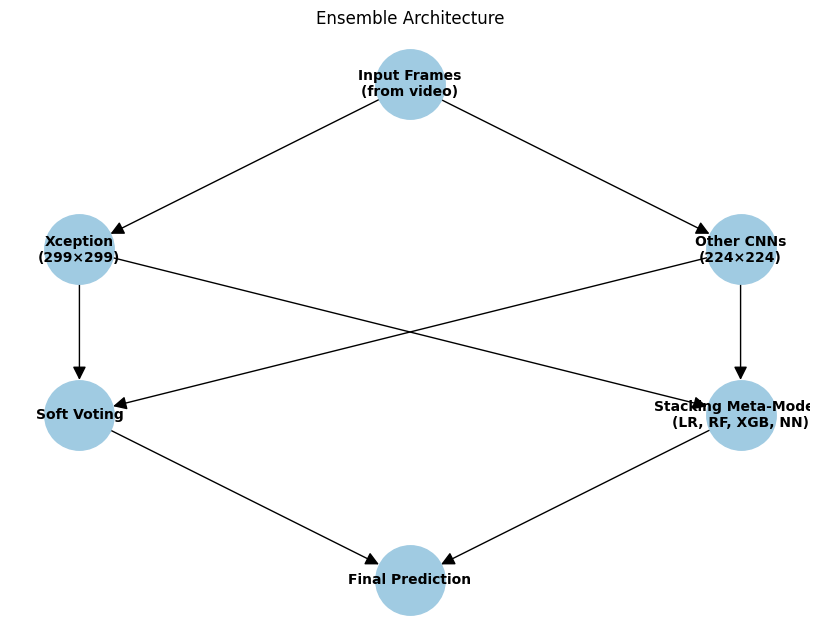

In [124]:
import matplotlib.pyplot as plt
import networkx as nx

# Create directed graph
G = nx.DiGraph()
# Add nodes
G.add_node("Input Frames\n(from video)")
G.add_node("Xception\n(299×299)")
G.add_node("Other CNNs\n(224×224)")
G.add_node("Soft Voting")
G.add_node("Stacking Meta-Models\n(LR, RF, XGB, NN)")
G.add_node("Final Prediction")

# Add edges
G.add_edge("Input Frames\n(from video)", "Xception\n(299×299)")
G.add_edge("Input Frames\n(from video)", "Other CNNs\n(224×224)")
G.add_edge("Xception\n(299×299)", "Soft Voting")
G.add_edge("Other CNNs\n(224×224)", "Soft Voting")
G.add_edge("Xception\n(299×299)", "Stacking Meta-Models\n(LR, RF, XGB, NN)")
G.add_edge("Other CNNs\n(224×224)", "Stacking Meta-Models\n(LR, RF, XGB, NN)")
G.add_edge("Soft Voting", "Final Prediction")
G.add_edge("Stacking Meta-Models\n(LR, RF, XGB, NN)", "Final Prediction")

# Define positions
pos = {
    "Input Frames\n(from video)": (0, 0),
    "Xception\n(299×299)": (-1, -1),
    "Other CNNs\n(224×224)": (1, -1),
    "Soft Voting": (-1, -2),
    "Stacking Meta-Models\n(LR, RF, XGB, NN)": (1, -2),
    "Final Prediction": (0, -3),
}

# Draw graph
plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_size=2500, node_color="#A0CBE2", 
        arrowsize=20, font_size=10, font_weight='bold')
plt.title("Ensemble Architecture")
plt.axis('off')
plt.tight_layout()
# Save the diagram
plt.savefig('C:/Users/Admin/Downloads/SVNIT/M.tech/2nd Sem/Minor project/Ensemble_Learning_Soft_Voting/ensemble_architecture.png', dpi=300)  
plt.show()